In [1]:
import pandas as pd
import matplotlib
import ast
#matplotlib.use('Agg')
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings
warnings.filterwarnings('ignore')

In [2]:
#폰트 설정(없으면 영문으로 나옴)
try:
    font_path = [f for f in fm.findSystemFonts() if 'NanumGothic' in f or 'Malgun' in f or 'AppleGothic' in f]
    if font_path:
        plt.rcParams['font.family'] = fm.FontProperties(fname=font_path[0]).get_name()
    else:
        plt.rcParams['font.family'] = 'DejaVu Sans'
except:
    plt.rcParams['font.family'] = 'DejaVu Sans'

plt.rcParams['axes.unicode_minus'] = False

In [4]:
full = pd.read_csv('../Soyun_EDA/preprocessed_final.csv')

In [5]:
full.columns

Index(['customer_id', 'event', 'time', 'amount', 'offer_id', 'day', 'reward',
       'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email',
       'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio',
       'offer_strength', 'gender', 'age', 'became_member_on', 'income',
       'is_profile_missing', 'age_group', 'age_gender', 'income_group'],
      dtype='str')

In [6]:
full[['time']]

,time
0,0
1,0
2,0
3,0
4,0
...,...
306529,714
306530,714
306531,714
306532,714


In [7]:
full.isnull().sum()

customer_id                0
event                      0
time                       0
amount                167581
offer_id              138953
day                        0
reward                138953
difficulty            138953
duration              138953
offer_type            138953
ch_web                138953
ch_email              138953
ch_mobile             138953
ch_social             138953
channel_count         138953
reward_ratio          138953
offer_strength        138953
gender                     0
age                    33772
became_member_on           0
income                     0
is_profile_missing         0
age_group                  0
age_gender                 0
income_group               0
dtype: int64

In [8]:
full.dtypes

customer_id               str
event                     str
time                    int64
amount                float64
offer_id                  str
day                     int64
reward                float64
difficulty            float64
duration              float64
offer_type                str
ch_web                float64
ch_email              float64
ch_mobile             float64
ch_social             float64
channel_count         float64
reward_ratio          float64
offer_strength        float64
gender                    str
age                   float64
became_member_on          str
income                float64
is_profile_missing      int64
age_group                 str
age_gender                str
income_group              str
dtype: object

In [9]:
# 날짜 변환 (혹시 안 했으면)
full['became_member_on'] = pd.to_datetime(full['became_member_on'], errors='coerce')

# 가입 연도
full['join_year'] = full['became_member_on'].dt.year

# 가입 월 (숫자)
full['join_month'] = full['became_member_on'].dt.month

# 가입 연-월 (문자형)
full['join_year_month'] = full['became_member_on'].dt.strftime('%Y-%m')

# cohort
full['join_cohort'] = full['became_member_on'].dt.to_period('M')

In [10]:
print("[ 가입 연도 분포 ]")
display(full['join_year'].value_counts().sort_index())

print("[ 가입 월 분포 ]")
display(full['join_month'].value_counts().sort_index())

print("[ Cohort 분포 ]")
display(full['join_cohort'].value_counts().sort_index())

[ 가입 연도 분포 ]


join_year
2013      6344
2014     15207
2015     38492
2016     72780
2017    113564
2018     60147
Name: count, dtype: int64

[ 가입 월 분포 ]


join_month
1     28161
2     21715
3     23366
4     23241
5     22953
6     22628
7     23984
8     29559
9     27622
10    28558
11    26386
12    28361
Name: count, dtype: int64

[ Cohort 분포 ]


join_cohort
2013-07     119
2013-08    1467
2013-09    1249
2013-10    1264
2013-11    1024
           ... 
2018-03    8505
2018-04    8176
2018-05    8370
2018-06    7831
2018-07    7085
Freq: M, Name: count, Length: 61, dtype: int64

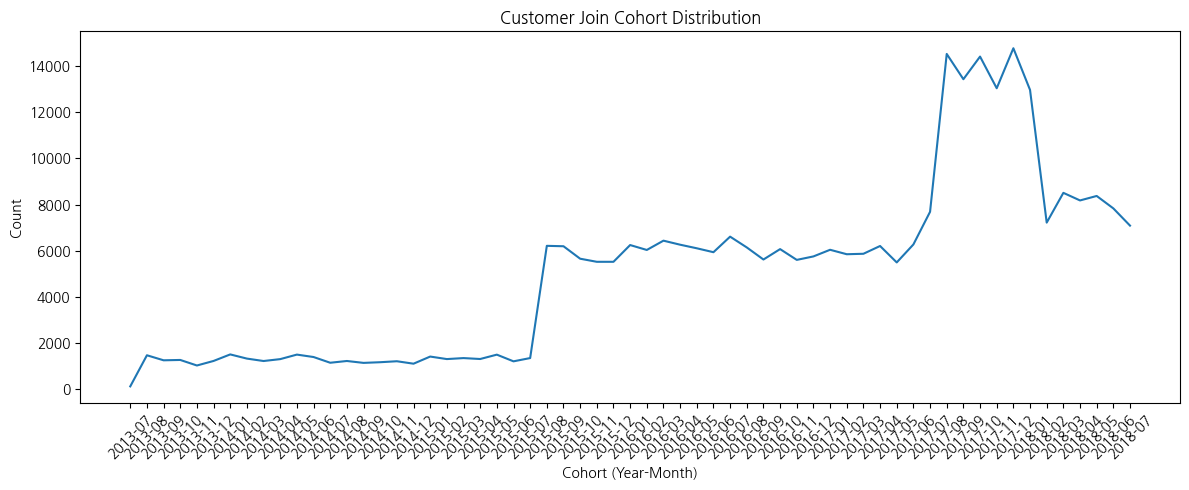

In [11]:
cohort_counts = full['join_cohort'].value_counts().sort_index()

import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(cohort_counts.index.astype(str), cohort_counts.values)

plt.xticks(rotation=45)
plt.title('Customer Join Cohort Distribution')
plt.xlabel('Cohort (Year-Month)')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

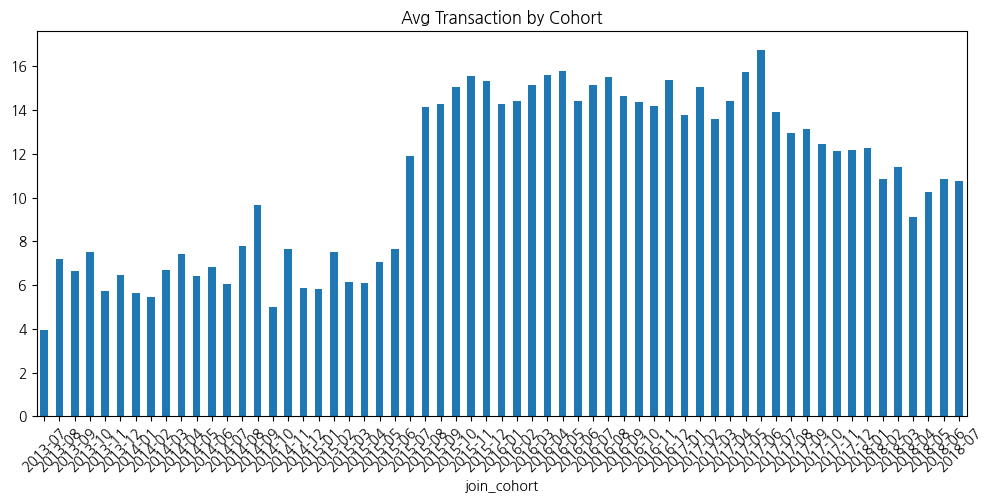

In [12]:
tx = full[full['event'] == 'transaction'].copy()

cohort_avg = (
    tx.groupby('join_cohort')['amount']
    .mean()
)

cohort_avg.plot(kind='bar', figsize=(12,5), title='Avg Transaction by Cohort')
plt.xticks(rotation=45)
plt.show()

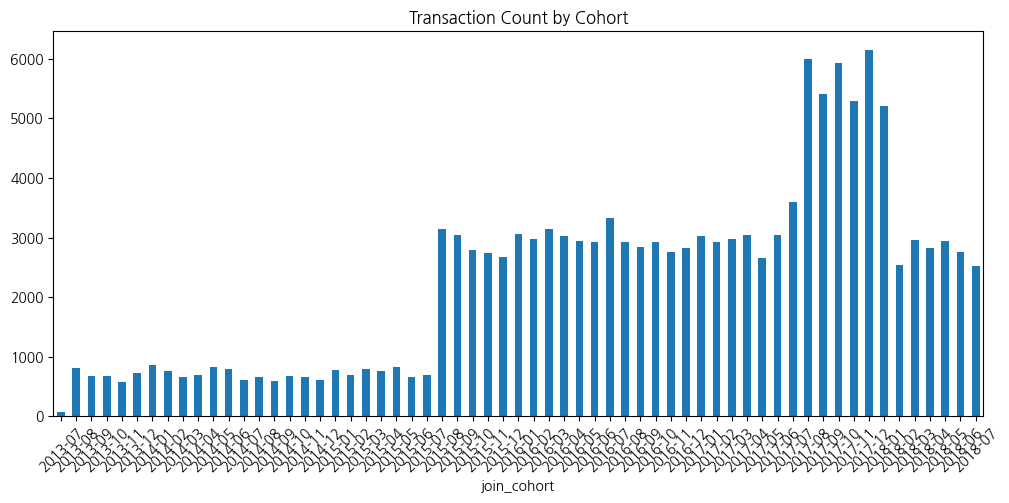

In [13]:
cohort_freq = (
    tx.groupby('join_cohort')['amount']
    .count()
)

cohort_freq.plot(kind='bar', figsize=(12,5), title='Transaction Count by Cohort')
plt.xticks(rotation=45)
plt.show()

In [14]:
full['offer_type'].value_counts() #bogo = buy one get one

offer_type
bogo             71617
discount         69898
informational    26066
Name: count, dtype: int64

In [16]:
print("=" * 50)
print("[ 기본 정보 ]")
print("=" * 50)
print(f"전체 행 수  : {len(full):,}")
print(f"고유 고객 수 : {full['customer_id'].nunique():,}")
print(f"컬럼 수     : {full.shape[1]}")

[ 기본 정보 ]
전체 행 수  : 306,534
고유 고객 수 : 17,000
컬럼 수     : 29


In [17]:
#-----------------------
# 이벤트 분포
#-----------------------

event = full['event'].value_counts()
for name, count in event.items():
    pct = count / len(full) * 100
    print(f"{name:<25} {count:>7,}건  ({pct:.1f}%)")

transaction               138,953건  (45.3%)
offer received             76,277건  (24.9%)
offer viewed               57,725건  (18.8%)
offer completed            33,579건  (11.0%)


In [19]:
# ----------------------
# 퍼널 수치
#-----------------------

n_received = full[full['event'] == 'offer received']['customer_id'].nunique()
n_viewed = full[full['event'] == 'offer viewed']['customer_id'].nunique()
n_completed = full[full['event'] == 'offer completed']['customer_id'].nunique()
n_transaction = full[full['event'] == 'transaction']['customer_id'].nunique()

print(f"오퍼 수신 고객 : {n_received:,}명")
print(f"오퍼 조회 고객 : {n_viewed:,}명 (수신 대비 {n_viewed / n_received * 100:.1f}%)")
print(f"오퍼 완료 고객 : {n_completed:,}명 (조회 대비 {n_completed / n_viewed * 100:.1f}%)")
print(f"트랜잭션 고객 : {n_transaction:,}명")

오퍼 수신 고객 : 16,994명
오퍼 조회 고객 : 16,834명 (수신 대비 99.1%)
오퍼 완료 고객 : 12,774명 (조회 대비 75.9%)
트랜잭션 고객 : 16,578명


In [21]:
full.columns

Index(['customer_id', 'event', 'time', 'amount', 'offer_id', 'day', 'reward',
       'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email',
       'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio',
       'offer_strength', 'gender', 'age', 'became_member_on', 'income',
       'is_profile_missing', 'age_group', 'age_gender', 'income_group',
       'join_year', 'join_month', 'join_year_month', 'join_cohort'],
      dtype='str')

In [22]:
# ==========================
# viewed 없이 completed 이벤트 플래그
# ==========================
df_view = full[full['event'] == 'offer viewed'][['customer_id', 'offer_id', 'time']] # view 이벤트 테이블
df_complete = full[full['event'] == 'offer completed'][['customer_id', 'offer_id', 'time']] # complete 이벤트 테이블
merged_df = pd.merge(df_complete, df_view, on=['customer_id', 'offer_id'], how='left', suffixes=('_comp', '_view'))
merged_df['is_aware'] = merged_df['time_view'] < merged_df['time_comp'] 

# is_aware가 True인 것을 가장 위로 올리고 (True는 보통 1, False는 0이므로 내림차순 정렬)
# 그중에서도 완료 직전의 조회를 찾기 위해 time_view를 내림차순 정렬
merged_df = merged_df.sort_values(
    by=['customer_id', 'time_comp', 'is_aware', 'time_view'], 
    ascending=[True, True, False, False] 
).drop_duplicates(
    subset=['customer_id', 'offer_id', 'time_comp'], 
    keep='first'
)
print(len(df_complete), len(merged_df))
dup_comp = df_complete.duplicated(subset=['customer_id', 'offer_id', 'time']).sum()
print(dup_comp)
display(merged_df)

33579 33182
397


,customer_id,offer_id,time_comp,time_view,is_aware
19009,0009655768c64bdeb2e877511632db8f,f19421c1d4aa40978ebb69ca19b0e20d,414,456.0,False
29211,0009655768c64bdeb2e877511632db8f,fafdcd668e3743c1bb461111dcafc2a4,528,540.0,False
33136,0009655768c64bdeb2e877511632db8f,2906b810c7d4411798c6938adc9daaa5,576,NaN,False
11281,0011e0d4e6b944f998e987f904e8c1e5,2298d6c36e964ae4a3e7e9706d1fb8c2,252,186.0,True
33157,0011e0d4e6b944f998e987f904e8c1e5,9b98b8c7a33c4b65b9aebfe6a799e6d9,576,516.0,True
...,...,...,...,...,...
8406,ffff82501cea40309d5fdd7edcca4a07,0b1e1539f2cc45b7b9fa7c272da2e1d7,198,174.0,True
16771,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,384,354.0,True
18926,ffff82501cea40309d5fdd7edcca4a07,2906b810c7d4411798c6938adc9daaa5,414,354.0,True
26299,ffff82501cea40309d5fdd7edcca4a07,9b98b8c7a33c4b65b9aebfe6a799e6d9,504,534.0,False


In [24]:
#미인지 고객
unaware = merged_df[~merged_df['is_aware']].shape[0]
total_c = len(merged_df)
print(f"\n  미인지 완료 (viewed 없이 completed) : {unaware:,}건 / {total_c:,}건 ({unaware/total_c*100:.1f}%)")


  미인지 완료 (viewed 없이 completed) : 10,869건 / 33,182건 (32.8%)


In [25]:
#오퍼 유형별 분포
print("=" * 50)
print("[ 오퍼 유형별 분포 ]")
print("=" * 50)
offer_ev = full[full['event'] != 'transaction'].groupby(['offer_type', 'event']).size().unstack(fill_value=0)
print(offer_ev)

[ 오퍼 유형별 분포 ]
event          offer completed  offer received  offer viewed
offer_type                                                  
bogo                     15669           30499         25449
discount                 17910           30543         21445
informational                0           15235         10831


In [29]:
#오퍼 유형별 완료율
for oftype in ['bogo', 'discount']:
    df_o = full[full['offer_type'] == oftype]
    r = df_o[df_o['event'] == 'offer received']['customer_id'].nunique()
    c = df_o[df_o['event'] == 'offer completed']['customer_id'].nunique()
    print(f"  {oftype:<12} 수신 {r:,}명  완료 {c:,}명  완료율 {c/r*100:.1f}%")

  bogo         수신 14,992명  완료 9,263명  완료율 61.8%
  discount     수신 14,945명  완료 10,289명  완료율 68.8%


In [32]:
#고객 단위별 집계(중복 제거)
customer = full[['customer_id','gender','age','age_group','age_gender','income','income_group']].drop_duplicates('customer_id')

print(f"총 고객 수: {len(customer):,}명")

총 고객 수: 17,000명


In [33]:
print(" [성별]")
for v, c in customer['gender'].value_counts(dropna=False).items():
    print(f"  {v:<10} {c:,}명  ({c/len(customer)*100:.1f}%)")


 [성별]
  M          8,484명  (49.9%)
  F          6,129명  (36.1%)
  Unknown    2,175명  (12.8%)
  O          212명  (1.2%)


In [34]:
gender_df = (
    customer['gender']
    .value_counts(dropna=False)
    .rename_axis('gender')
    .reset_index(name='count')
)

# 비율 추가
gender_df['ratio'] = gender_df['count'] / len(customer) * 100
gender_df

,gender,count,ratio
0,M,8484,49.905882
1,F,6129,36.052941
2,Unknown,2175,12.794118
3,O,212,1.247059


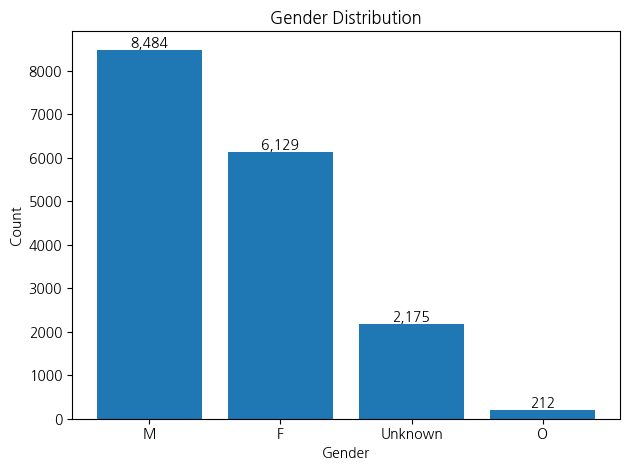

In [35]:

plt.figure()
plt.bar(gender_df['gender'], gender_df['count'])

# 값 표시
for i, v in enumerate(gender_df['count']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.title('Gender Distribution')
plt.xlabel('Gender')
plt.ylabel('Count')

plt.tight_layout()
plt.show()

In [36]:
print("[ 연령대 ]")
age_order = ['20대 미만', '20대', '30대', '40대', '50대', '60대 이상', '누락']
for v in age_order:
    c = (customer['age_group'] == v).sum()
    print(f"    {v:<8} {c:>5,}명  ({c/len(customer)*100:.1f}%)")

[ 연령대 ]
    20대 미만     205명  (1.2%)
    20대      1,369명  (8.1%)
    30대      1,526명  (9.0%)
    40대      2,309명  (13.6%)
    50대      3,541명  (20.8%)
    60대 이상   5,875명  (34.6%)
    누락       2,175명  (12.8%)


In [37]:

age_df = (
    customer['age_group']
    .value_counts(dropna=False)
    .rename_axis('age_group')
    .reset_index(name='count')
)
# 순서 지정 
age_df['age_group'] = pd.Categorical(age_df['age_group'], categories=age_order, ordered=True)

# 정렬
age_df = age_df.sort_values('age_group')

# 비율 추가
age_df['ratio'] = age_df['count'] / len(customer) * 100

age_df

,age_group,count,ratio
6,20대 미만,205,1.205882
5,20대,1369,8.052941
4,30대,1526,8.976471
2,40대,2309,13.582353
1,50대,3541,20.829412
0,60대 이상,5875,34.558824
3,누락,2175,12.794118


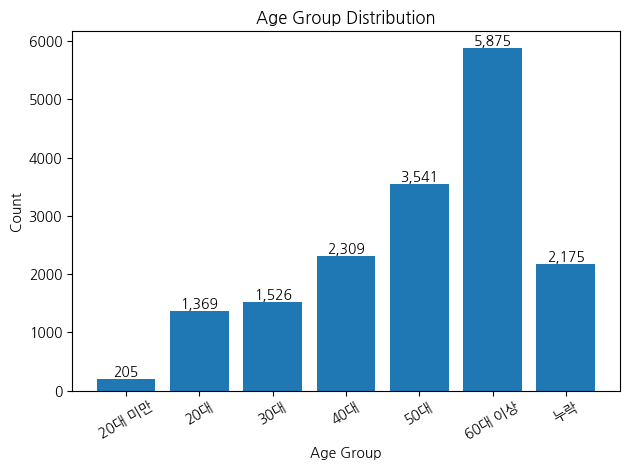

In [38]:
plt.figure()
plt.bar(age_df['age_group'], age_df['count'])

# 값 표시
for i, v in enumerate(age_df['count']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.title('Age Group Distribution')
plt.xlabel('Age Group')
plt.ylabel('Count')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [39]:
print(f"\n  나이 기술통계 (누락 제외):")
age_valid = customer[customer['age_group'] != '누락']['age']
print(f"    평균 {age_valid.mean():.1f}세 / 중앙값 {age_valid.median():.0f}세 / 최소 {age_valid.min():.0f}세 / 최대 {age_valid.max():.0f}세")


  나이 기술통계 (누락 제외):
    평균 54.4세 / 중앙값 55세 / 최소 18세 / 최대 101세


In [40]:
print(" [ 소득 구간 ]")
inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']
for v in inc_order:
    c = (customer['income_group'] == v).sum()
    print(f"    {v:<10} {c:>5,}명  ({c/len(customer)*100:.1f}%)")

 [ 소득 구간 ]
    누락         2,175명  (12.8%)
    5만 미만      3,781명  (22.2%)
    5-7.5만     6,446명  (37.9%)
    7.5-10만    3,505명  (20.6%)
    10만 이상     1,093명  (6.4%)


In [41]:
age_gender_order = ['미기입', 'Others']

age_bins = ['20세 미만', '20대', '30대', '40대', '50대', '60대', '60+']
genders = ['남성', '여성']

for g in genders:
    for a in age_bins:
        age_gender_order.append(f"{a} {g}")

In [42]:
result = full['age_gender'].value_counts().reindex(age_gender_order, fill_value=0)

print("[ 연령 × 성별 구간 ]")
for v, c in result.items():
    print(f"    {v:<15} {c:>5,}명  ({c/len(full)*100:.1f}%)")

[ 연령 × 성별 구간 ]
    미기입             33,772명  (11.0%)
    Others          3,971명  (1.3%)
    20세 미만 남성       3,042명  (1.0%)
    20대 남성          18,290명  (6.0%)
    30대 남성          19,563명  (6.4%)
    40대 남성          26,078명  (8.5%)
    50대 남성          34,689명  (11.3%)
    60대 남성          29,034명  (9.5%)
    60+ 남성          24,994명  (8.2%)
    20세 미만 여성         920명  (0.3%)
    20대 여성          8,379명  (2.7%)
    30대 여성          10,231명  (3.3%)
    40대 여성          15,635명  (5.1%)
    50대 여성          28,060명  (9.2%)
    60대 여성          24,112명  (7.9%)
    60+ 여성          25,764명  (8.4%)


In [43]:
df_age_gender = (
    full['age_gender']
    .value_counts()
    .reindex(age_gender_order, fill_value=0)
    .to_frame(name='count')
)

df_age_gender['ratio(%)'] = (df_age_gender['count'] / len(full) * 100).round(1)

display(df_age_gender)

,count,ratio(%)
age_gender,,
미기입,33772,11.0
Others,3971,1.3
20세 미만 남성,3042,1.0
20대 남성,18290,6.0
30대 남성,19563,6.4
40대 남성,26078,8.5
50대 남성,34689,11.3
60대 남성,29034,9.5
60+ 남성,24994,8.2


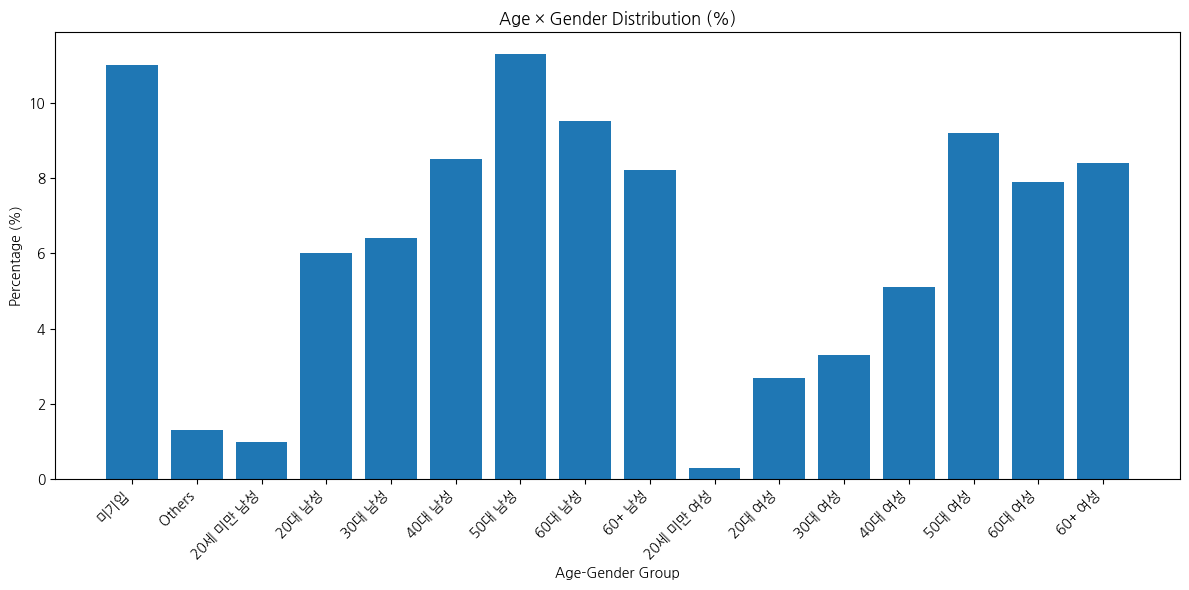

In [44]:
plt.figure(figsize=(12,6))

plt.bar(df_age_gender.index, df_age_gender['ratio(%)'])

plt.xticks(rotation=45, ha='right')
plt.title('Age × Gender Distribution (%)')
plt.xlabel('Age-Gender Group')
plt.ylabel('Percentage (%)')

plt.tight_layout()
plt.show()

In [45]:
import pandas as pd

inc_order = ['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상']

# count 계산 (순서 유지)
inc_df = pd.DataFrame({
    'income_group': inc_order,
    'count': [(customer['income_group'] == v).sum() for v in inc_order]
})

# 비율 추가
inc_df['ratio'] = inc_df['count'] / len(customer) * 100

inc_df

,income_group,count,ratio
0,누락,2175,12.794118
1,5만 미만,3781,22.241176
2,5-7.5만,6446,37.917647
3,7.5-10만,3505,20.617647
4,10만 이상,1093,6.429412


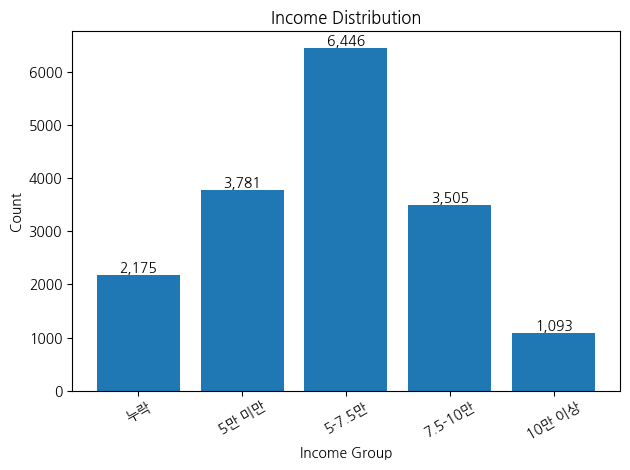

In [46]:
plt.figure()
plt.bar(inc_df['income_group'], inc_df['count'])

# 값 표시
for i, v in enumerate(inc_df['count']):
    plt.text(i, v, f"{v:,}", ha='center', va='bottom')

plt.title('Income Distribution')
plt.xlabel('Income Group')
plt.ylabel('Count')

plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [47]:
print(f"누락 제외:")
inc_valid = customer[customer['income_group'] != '누락']['income']
print(f" 평균 ${inc_valid.mean():,.0f} , 중앙값 ${inc_valid.median():,.0f} , 최소 ${inc_valid.min():,.0f} , 최대 ${inc_valid.max():,.0f}")

누락 제외:
 평균 $65,405 , 중앙값 $64,000 , 최소 $30,000 , 최대 $120,000


In [59]:
#거래 금액 분포 
print( "=" * 50)
print("[ 거래 금액 분포 ]")
print("=" * 50)
tx = full[full['event'] == 'transaction']['amount']
print(f"  거래 건수  : {len(tx):,}건")
print(f"  평균       : ${tx.mean():.2f}")
print(f"  중앙값     : ${tx.median():.2f}")
print(f"  최솟값     : ${tx.min():.2f}")
print(f"  최댓값     : ${tx.max():.2f}")
print(f"  표준편차   : ${tx.std():.2f}")
print(f"  이상값(>200달러) : {(tx > 200).sum():,}건  ({(tx>200).mean()*100:.2f}%)")

# 고객별 총 거래금액
cust_tx = full[full['event'] == 'transaction'].groupby('customer_id')['amount'].sum()
print(f"\n  고객별 총 거래금액:")
print(f"    평균   : ${cust_tx.mean():.2f}")
print(f"    중앙값 : ${cust_tx.median():.2f}")
print(f"    최댓값 : ${cust_tx.max():.2f}")

[ 거래 금액 분포 ]
  거래 건수  : 138,953건
  평균       : $12.78
  중앙값     : $8.89
  최솟값     : $0.05
  최댓값     : $1062.28
  표준편차   : $30.25
  이상값(>200달러) : 371건  (0.27%)

  고객별 총 거래금액:
    평균   : $107.10
    중앙값 : $72.41
    최댓값 : $1608.69


In [49]:
#채널별 오퍼 수 
print("\n" + "=" * 55)
print("[채널별 오퍼 발송 현황 ]")
print("=" * 55)
offer_log = full[full['event'] == 'offer received']
for ch in ['ch_web', 'ch_email', 'ch_mobile', 'ch_social']:
    cnt = offer_log[ch].sum()
    pct = cnt / len(offer_log) * 100
    print(f"  {ch:<12} {int(cnt):>7,}건  ({pct:.1f}%)")

print(f"\n  채널 수별 오퍼:")
for n, c in offer_log['channel_count'].value_counts().sort_index().items():
    print(f"    {int(n)}개 채널  {c:>7,}건  ({c/len(offer_log)*100:.1f}%)")



[채널별 오퍼 발송 현황 ]
  ch_web        61,001건  (80.0%)
  ch_email      76,277건  (100.0%)
  ch_mobile     68,609건  (89.9%)
  ch_social     45,683건  (59.9%)

  채널 수별 오퍼:
    2개 채널    7,668건  (10.1%)
    3개 채널   38,202건  (50.1%)
    4개 채널   30,407건  (39.9%)


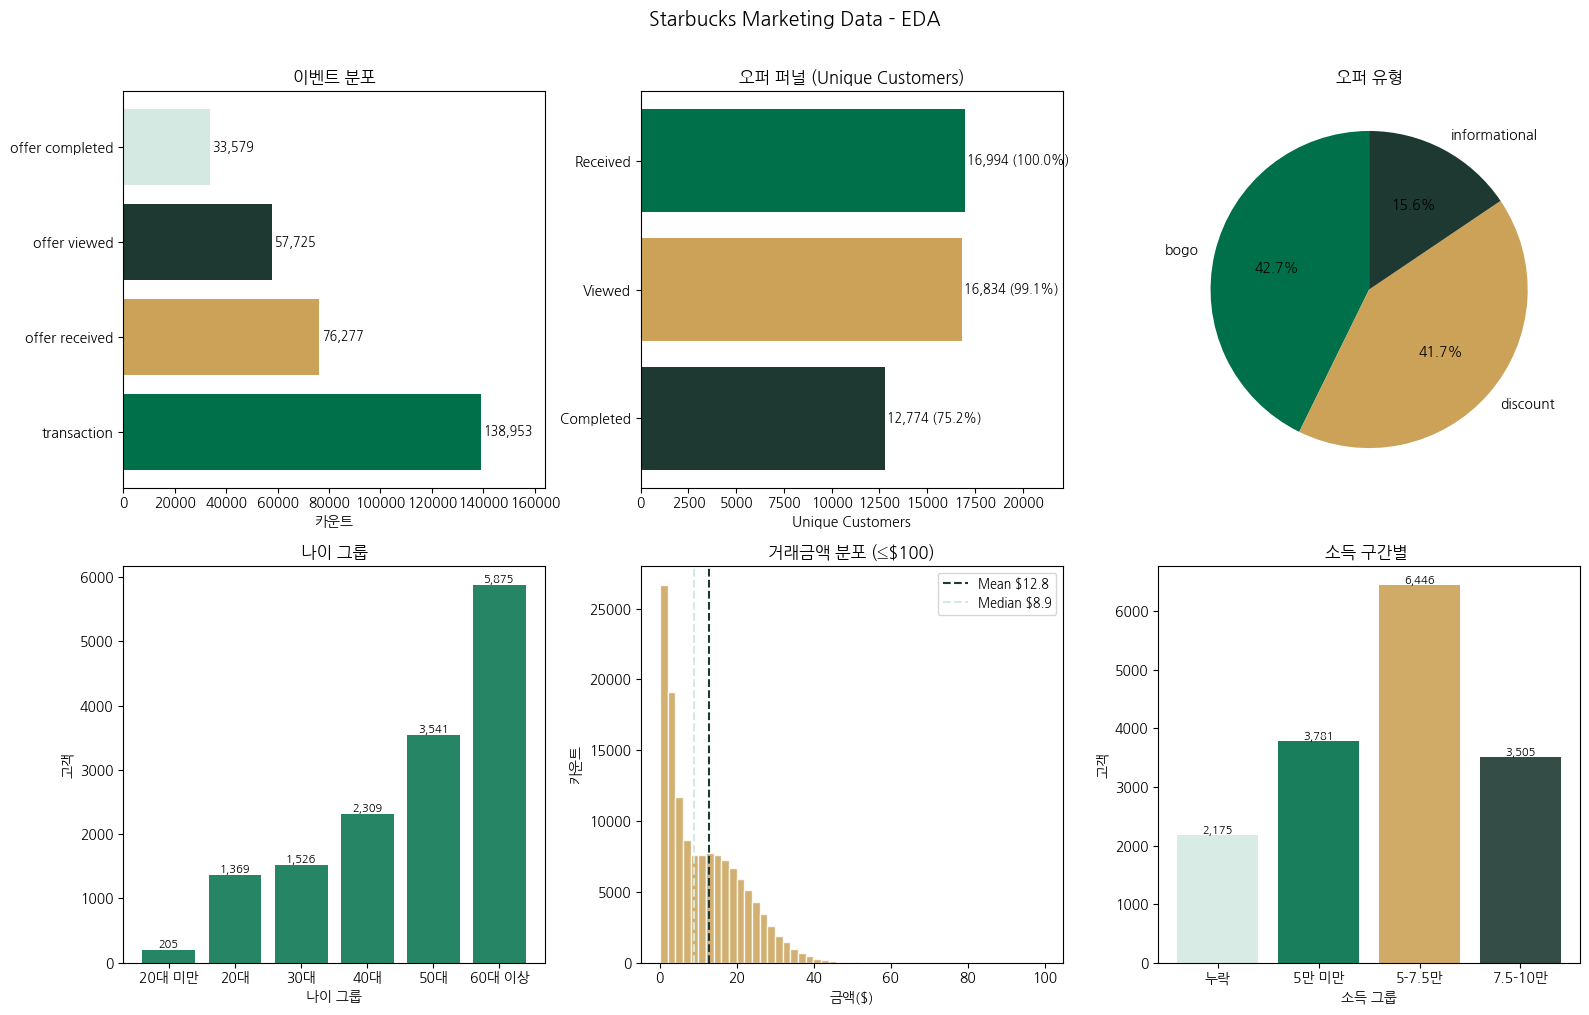

In [50]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Starbucks Marketing Data - EDA', fontsize=14, fontweight='bold', y=1.01)

colors_main = ['#00704A', '#CBA258', '#1E3932', '#D4E9E2', '#006241', '#F2C75C']

# 차트 1: 이벤트 분포
ax1 = axes[0, 0]
ev_data = full['event'].value_counts()
bars = ax1.barh(ev_data.index, ev_data.values, color=colors_main[:4])
ax1.set_title('이벤트 분포', fontweight='bold')
ax1.set_xlabel('카운트')
for bar, val in zip(bars, ev_data.values):
    ax1.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
             f'{val:,}', va='center', fontsize=9)
ax1.set_xlim(0, max(ev_data.values) * 1.18)

# 차트 2: 퍼널
ax2 = axes[0, 1]
funnel_labels = ['Received', 'Viewed', 'Completed']
funnel_vals   = [n_received, n_viewed, n_completed]
funnel_colors = ['#00704A', '#CBA258', '#1E3932']
bars2 = ax2.barh(funnel_labels[::-1], funnel_vals[::-1], color=funnel_colors[::-1])
ax2.set_title('오퍼 퍼널 (Unique Customers)', fontweight='bold')
ax2.set_xlabel('Unique Customers')
for bar, val, lbl in zip(bars2, funnel_vals[::-1], funnel_labels[::-1]):
    pct = val / n_received * 100
    ax2.text(bar.get_width() + 100, bar.get_y() + bar.get_height()/2,
             f'{val:,} ({pct:.1f}%)', va='center', fontsize=9)
ax2.set_xlim(0, max(funnel_vals) * 1.3)

# 차트 3: 오퍼 유형별
ax3 = axes[0, 2]
ot = full[full['event'] != 'transaction']['offer_type'].value_counts()
ax3.pie(ot.values, labels=ot.index, autopct='%1.1f%%',
        colors=['#00704A', '#CBA258', '#1E3932'], startangle=90)
ax3.set_title('오퍼 유형', fontweight='bold')

# 차트 4: 연령대
ax4 = axes[1, 0]
age_vals = [customer['age_group'].value_counts().get(a, 0) for a in age_order[:-1]]
ax4.bar(age_order[:-1], age_vals, color='#00704A', alpha=0.85)
ax4.set_title('나이 그룹', fontweight='bold')
ax4.set_xlabel('나이 그룹')
ax4.set_ylabel('고객')
for i, v in enumerate(age_vals):
    ax4.text(i, v + 30, f'{v:,}', ha='center', fontsize=8)

# 차트 5: 거래금액 분포 (이상값 제외)
ax5 = axes[1, 1]
tx_plot = tx[tx <= 100]
ax5.hist(tx_plot, bins=50, color='#CBA258', alpha=0.85, edgecolor='white')
ax5.axvline(tx.mean(),   color='#1E3932', linestyle='--', linewidth=1.5, label=f'Mean ${tx.mean():.1f}')
ax5.axvline(tx.median(), color='#D4E9E2', linestyle='--', linewidth=1.5, label=f'Median ${tx.median():.1f}')
ax5.set_title('거래금액 분포 (≤$100)', fontweight='bold')
ax5.set_xlabel('금액($)')
ax5.set_ylabel('카운트')
ax5.legend(fontsize=9)

# 차트 6: 소득 구간
ax6 = axes[1, 2]
inc_vals = [customer['income_group'].value_counts().get(i, 0) for i in inc_order[:-1]]
bars6 = ax6.bar(inc_order[:-1], inc_vals, color=['#D4E9E2','#00704A','#CBA258','#1E3932'], alpha=0.9)
ax6.set_title('소득 구간별 ', fontweight='bold')
ax6.set_xlabel('소득 그룹')
ax6.set_ylabel('고객')
for bar, val in zip(bars6, inc_vals):
    ax6.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
             f'{val:,}', ha='center', fontsize=8)

plt.tight_layout()

In [51]:
full['age'].describe()

count    272762.000000
mean         53.840696
std          17.551337
min          18.000000
25%          41.000000
50%          55.000000
75%          66.000000
max         101.000000
Name: age, dtype: float64

In [52]:
tx = full[full['event'] == 'transaction'].copy()

In [53]:
# income 기준
inc_avg = (
    tx.groupby('income_group')['amount']
    .mean()
    .reindex(['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상'])
)

# age_gender 기준
age_gender_avg = (
    tx.groupby('age_gender')['amount']
    .mean()
    .reindex(age_gender_order)
)

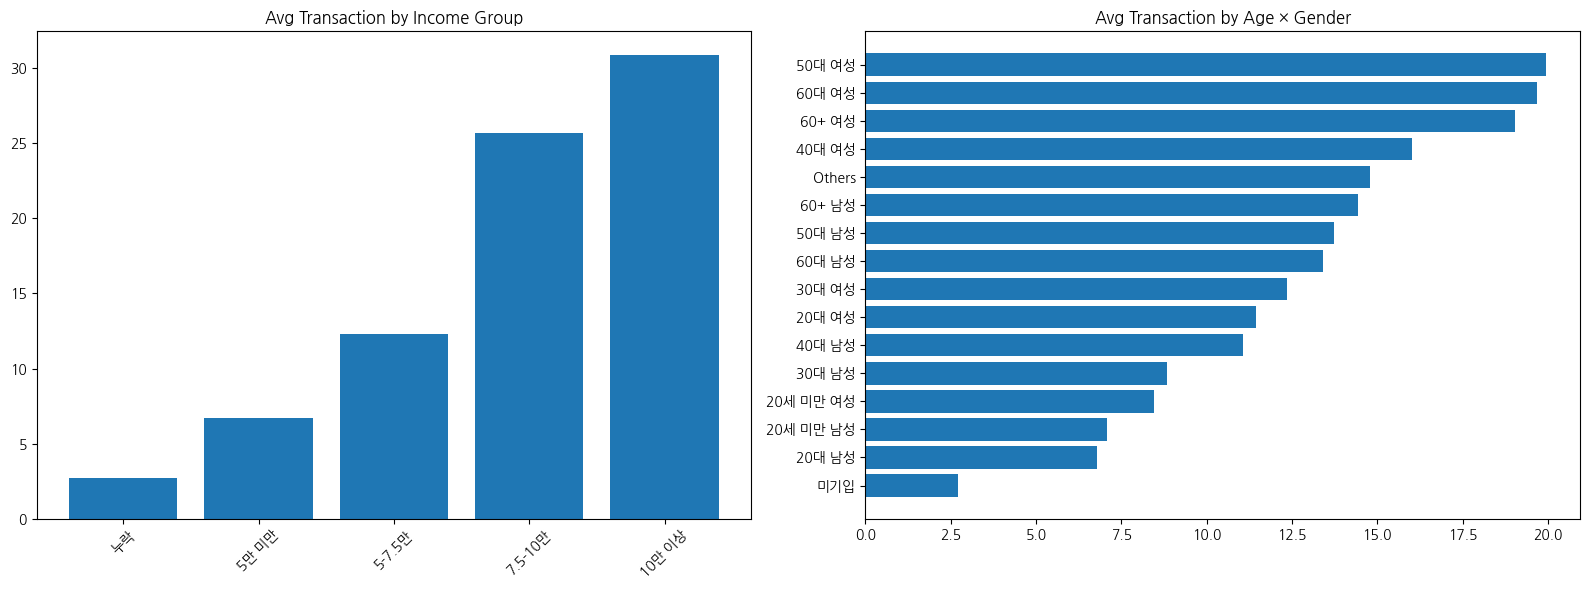

In [54]:
fig, axes = plt.subplots(1, 2, figsize=(16,6))

# income
axes[0].bar(inc_avg.index, inc_avg.values)
axes[0].set_title('Avg Transaction by Income Group')
axes[0].tick_params(axis='x', rotation=45)

# age_gender → horizontal
sorted_age = age_gender_avg.sort_values()

axes[1].barh(sorted_age.index, sorted_age.values)
axes[1].set_title('Avg Transaction by Age × Gender')

plt.tight_layout()
plt.show()

In [57]:
# transaction만
tx = full[full['event'] == 'transaction'].copy()

# 1인당 평균 transaction 금액
person_avg = (
    tx.groupby(['customer_id', 'income_group'])['amount']
    .mean()
    .reset_index()
)

# income_group별 "사람 평균의 평균"
income_avg_person = (
    person_avg.groupby('income_group')['amount']
    .mean()
    .reindex(['누락', '5만 미만', '5-7.5만', '7.5-10만', '10만 이상'])
)

# age_gender별 1인당 평균 transaction 금액
person_avg_age = (
    tx.groupby(['customer_id', 'age_gender'])['amount']
    .mean()
    .reset_index()
)

age_gender_avg_person = (
    person_avg_age.groupby('age_gender')['amount']
    .mean()
    .reindex(age_gender_order)
)

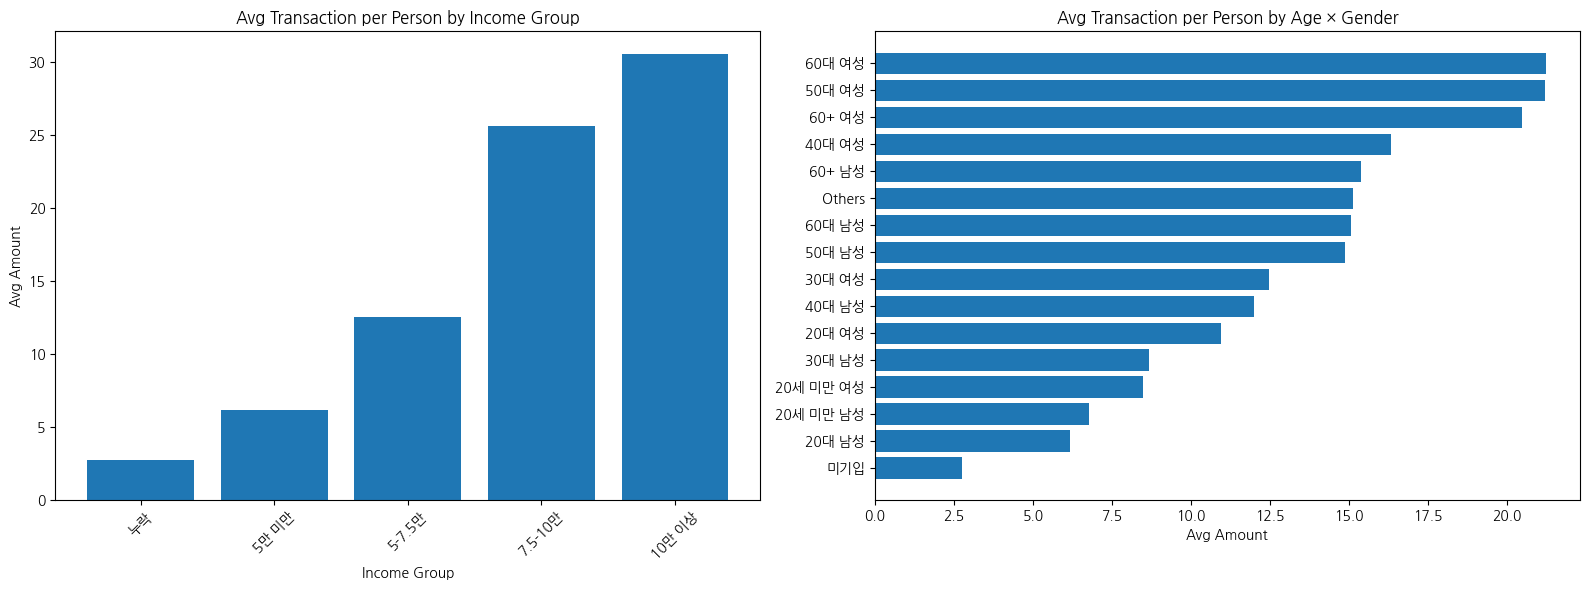

In [58]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# income
axes[0].bar(income_avg_person.index, income_avg_person.values)
axes[0].set_title('Avg Transaction per Person by Income Group')
axes[0].set_xlabel('Income Group')
axes[0].set_ylabel('Avg Amount')
axes[0].tick_params(axis='x', rotation=45)

# age_gender
sorted_age = age_gender_avg_person.sort_values()

axes[1].barh(sorted_age.index, sorted_age.values)
axes[1].set_title('Avg Transaction per Person by Age × Gender')
axes[1].set_xlabel('Avg Amount')

plt.tight_layout()
plt.show()

In [60]:

# full DataFrame (추가 칼럼 포함) 저장
full.to_csv('../Soyun_EDA/final_eda.csv', index=False)
print(f"저장 완료: final_eda.csv")
print(f"  행 수: {len(full):,}")
print(f"  칼럼 수: {full.shape[1]}")
print(f"  칼럼 목록: {list(full.columns)}")


저장 완료: final_eda.csv
  행 수: 306,534
  칼럼 수: 29
  칼럼 목록: ['customer_id', 'event', 'time', 'amount', 'offer_id', 'day', 'reward', 'difficulty', 'duration', 'offer_type', 'ch_web', 'ch_email', 'ch_mobile', 'ch_social', 'channel_count', 'reward_ratio', 'offer_strength', 'gender', 'age', 'became_member_on', 'income', 'is_profile_missing', 'age_group', 'age_gender', 'income_group', 'join_year', 'join_month', 'join_year_month', 'join_cohort']


cohort_index,0,1
join_cohort,,
2013-07,0.4,1.0
2013-08,1.0,NaN
2013-09,NaN,NaN
2013-10,NaN,NaN
2013-11,NaN,NaN


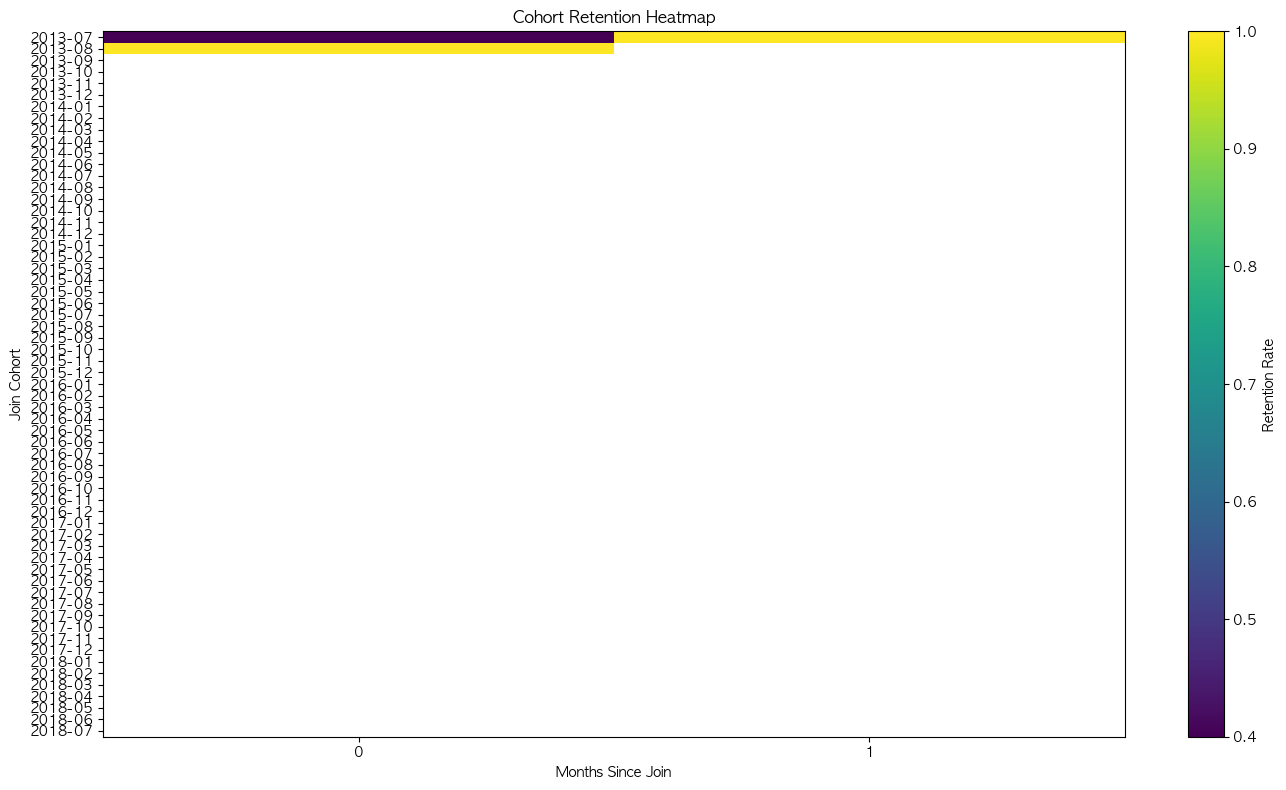

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt

# # 1. transaction만 사용
# tx = full[full['event'] == 'transaction'].copy()

# # 2. 날짜형
# full['became_member_on'] = pd.to_datetime(full['became_member_on'], errors='coerce')
# tx['became_member_on'] = pd.to_datetime(tx['became_member_on'], errors='coerce')

# # 3. join cohort
# full['join_cohort'] = full['became_member_on'].dt.to_period('M')
# tx['join_cohort'] = tx['became_member_on'].dt.to_period('M')

# # 4. relative time -> proxy tx date
# start_date = full['became_member_on'].min()
# tx['tx_date'] = start_date + pd.to_timedelta(tx['time'], unit='h')
# tx['tx_period'] = tx['tx_date'].dt.to_period('M')

# # 5. cohort index
# tx['cohort_index'] = (
#     (tx['tx_period'].dt.year - tx['join_cohort'].dt.year) * 12
#     + (tx['tx_period'].dt.month - tx['join_cohort'].dt.month)
# )

# # 6. 음수 제거
# tx = tx[tx['cohort_index'] >= 0].copy()

# # 7. 분자: cohort별/월별 active buyer 수
# cohort_data = (
#     tx.groupby(['join_cohort', 'cohort_index'])['customer_id']
#     .nunique()
#     .reset_index()
# )

# cohort_pivot = cohort_data.pivot(
#     index='join_cohort',
#     columns='cohort_index',
#     values='customer_id'
# )

# # 8. 분모: 해당 cohort 전체 가입자 수
# cohort_size = (
#     full[['customer_id', 'join_cohort']]
#     .drop_duplicates()
#     .groupby('join_cohort')['customer_id']
#     .nunique()
# )

# # 9. retention
# retention = cohort_pivot.divide(cohort_size, axis=0)

# # 10. 확인
# display(retention.iloc[:5, :5])

# # 11. heatmap
# plt.figure(figsize=(14, 8))
# plt.imshow(retention, aspect='auto')
# plt.colorbar(label='Retention Rate')

# plt.yticks(range(len(retention.index)), retention.index.astype(str))
# plt.xticks(range(len(retention.columns)), retention.columns)

# plt.xlabel('Months Since Join')
# plt.ylabel('Join Cohort')
# plt.title('Cohort Retention Heatmap')

# plt.tight_layout()
# plt.show()

In [ ]:
# cohort_check = tx[tx['join_cohort'] == '2013-07']

# print("전체 가입자 수:", full.loc[full['join_cohort'] == '2013-07', 'customer_id'].nunique())

# print("\n0개월차 구매자 수:")
# print(cohort_check.loc[cohort_check['cohort_index'] == 0, 'customer_id'].nunique())

# print("\n1개월차 구매자 수:")
# print(cohort_check.loc[cohort_check['cohort_index'] == 1, 'customer_id'].nunique())

전체 가입자 수: 5

0개월차 구매자 수:
2

1개월차 구매자 수:
5


In [ ]:
# first_tx = (
#     tx.groupby('customer_id')['cohort_index']
#     .min()
# )

# first_tx.value_counts().sort_index()

cohort_index
0    70
1     3
Name: count, dtype: int64

In [ ]:
# cohort_size = (
#     full[['customer_id', 'join_cohort']]
#     .drop_duplicates()
#     .groupby('join_cohort')['customer_id']
#     .nunique()
# )

# display(cohort_size.head())

join_cohort
2013-07     5
2013-08    68
2013-09    57
2013-10    56
2013-11    48
Freq: M, Name: customer_id, dtype: int64

In [ ]:
# valid_cohort = cohort_size[cohort_size >= 50].index
# retention_filtered = retention.loc[valid_cohort]

<Axes: xlabel='cohort_index'>

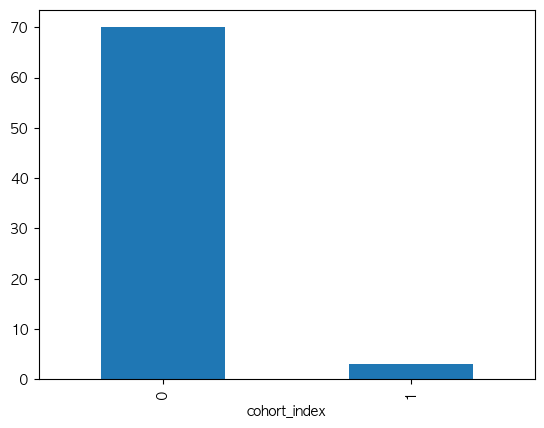

In [ ]:
# first_tx.value_counts().sort_index().plot(kind='bar')

In [74]:
# ============================================================
# [제외] 멤버십 기간 (membership_days) 생성 코드
# ------------------------------------------------------------
# ※ 이 코드는 보정(proxy) 기반으로 멤버십 기간을 추정하는 방식
# ※ time(상대시간) + became_member_on(절대시간) 혼합으로 정확도 한계 있음
# ※ 해석 리스크(실제 가입기간 왜곡) 때문에 메인 분석에서는 제외
# ============================================================

# 날짜 변환
# full['became_member_on'] = pd.to_datetime(full['became_member_on'], errors='coerce')

# 고객별 첫 오퍼 수신 시간 (상대시간)
# offer_received = (
#     full.loc[full['event'] == 'offer received', ['person', 'time']]
#     .groupby('person', as_index=False)['time']
#     .min()
#     .rename(columns={'time': 'first_offer_time'})
# )

# full = full.merge(offer_received, on='person', how='left')

# 수치형 변환
# full['first_offer_time'] = pd.to_numeric(full['first_offer_time'], errors='coerce')

# 가상의 기준일 설정 (가장 최근 가입일)
# t0 = full['became_member_on'].max()

# 오퍼 시점 추정 (proxy)
# full['offer_date'] = t0 + pd.to_timedelta(full['first_offer_time'], unit='h')

# 멤버십 기간 (가입 → 오퍼 시점, proxy)
# full['membership_days_at_offer'] = (full['offer_date'] - full['became_member_on']).dt.days

# 구간화 함수
# def member_period(days):
#     if pd.isna(days) or days < 0:
#         return '미기재'
#     elif days < 365:
#         return '신규 (1년 미만)'
#     elif days < 730:
#         return '중간 (1~2년)'
#     else:
#         return '장기 (2년+)'

# 그룹 컬럼 생성
# full['member_days_group'] = full['membership_days_at_offer'].apply(member_period)